# **Atividade Prática**
<font size=3>

- **Tema:** autocomplete.
- **Prazo de entrega:** 15 de Junho.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSfhkf8HoNNsr9WixEVVlxh8-pFK-rnXsLKN_OLRH_Tg5-5SmA/viewform?usp=sharing&ouid=111377632325147218671).

---

## **Enunciado:**
<font size=3>

Vamos realizar uma tarefa de **_autocomplete_** com o conjundo de dados [IMDB movie reviews](https://keras.io/api/datasets/imdb/), também disponível no diretório $\text{dataset/}\,$. Nesta tarefa, iremos encontrar o próximo *token* mais provável. Para isso, realize os seguintes passos atentamente:

### **1º Passo:**
<font size=3>

- Importe o *dataset* e realize uma amostragem dos dados a fim de capturar 500 textos de revisão;
- Defina os dados textuais em uma lista.


#### Resolução item 1

Vamos adicionar na resolução do item 1 algumas atividades que nos ajudarão a executar as tarefas seguintes.

In [2]:
# não é necessario montar o google drive por que estamos trabalhando com dados e processamento local
#from google.colab import drive
#drive.mount('/content/drive/')

##### Imports e definições globais

In [3]:
from collections import Counter
from keras import layers, Model
import keras_tuner as kt
from keras.metrics import SparseTopKCategoricalAccuracy
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib.ticker import FuncFormatter
import os
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorboard
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from tensorflow.keras.preprocessing.sequence import pad_sequences

RANDOM_STATE = 42

N_SAMPLES_TRAIN = 3_000 # numero de amostras de treinamento
N_SAMPLES_TEST = 500 # numero de amostras de teste

MAX_LEN = 16 # tamanho máximo das sequencias de tokens

In [4]:
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices("GPU"))
#tf.debugging.set_log_device_placement(True)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


##### Leitura dos dados

Na leitura dos dados vamos utilizar as variáveis globais `N_SAMPLES_TRAIN` e `N_SAMPLES_TEST` para leer um total de `N_SAMPLES_TRAIN + N_SAMPLES_TEST` amostras, sendo `N_SAMPLES_TRAIN` as amostras exclusivas de treino/validação e `N_SAMPLES_TEST` as amostras exclusivas para teste do modelo.

No momento da leitura do dataframe original aplicamos randomização na ordem dos elementos com `random_state=RANDOM_STATE` para garantir reprodutibilidade do experimento. Em seguida selecionamos em df_test as amostras desejadas, lembrando que já foram randomizadas na leitura, e sobrescrevemos o dataframe original com o conjunto de treino/validação. Mostramos finalmente a quantidade de amostras de cada conjunto e aluns exemplos de dados selecionados para conferência.

In [5]:
df = (
    pd.read_csv("./dataset/imdb.csv")
    .sample(
        frac=1,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

df_test = (
    df
    .iloc[
        N_SAMPLES_TRAIN:
        N_SAMPLES_TRAIN + N_SAMPLES_TEST
    ]
    .copy()
)

df = (
    df
    .iloc[:N_SAMPLES_TRAIN]
    .copy()
)

print("Desenvolvimento:", df.shape)
print("Teste externo:  ", df_test.shape)

df.head()

Desenvolvimento: (3000, 2)
Teste externo:   (500, 2)


,reviews,label
0,River's Edge is more than just the story of a ...,1
1,Evening is the beautiful story of the flawed l...,1
2,I question anyone saying they don't care for t...,1
3,This docu-drama is what you would expect from ...,1
4,"As several posters have ""hinted,"" this is a so...",0


##### Pré processamento dos dados

Inicialmente adotamos uma estratégia mais tradicional em relação aos exercícios que vinhamos trabalhando até então. Entretanto, durante as modelagem da rede, percebemos que o pré processamento especifico implementado abaixo ajudaria a melhorar nosso modelo. Em particular, notamos que o modelo poderia se beneficiar se aplicassemos algumas expansões de contrações em inglês específicas. Como durante o processo de modelagem adicionamos o GloVe com embeddings pré-treinados, notamos uma quantidade importante de tokens que não estavam nos embeddings do GloVe. Investigando quais tokens eram esses, notamos que uma grande parte representavam expansões que não estavam sendo bem tratadas no pre-processamento. Por isso, implementamos as funções a seguir.

In [6]:
CONTRACOES_COMUNS = [
    # Casos específicos com "'s" interpretado como "is".
    (r"\bit's\b", "it is"),
    (r"\bthat's\b", "that is"),
    (r"\bthere's\b", "there is"),
    (r"\bwhat's\b", "what is"),
    (r"\bwho's\b", "who is"),
    (r"\bhere's\b", "here is"),
    (r"\bwhere's\b", "where is"),
    (r"\bhow's\b", "how is"),

    # Contrações irregulares.
    (r"\bwon't\b", "will not"),
    (r"\bcan't\b", "can not"),
    (r"\bain't\b", "is not"),

    # Contrações regulares.
    (r"n't\b", " not"),
    (r"'re\b", " are"),
    (r"'ve\b", " have"),
    (r"'ll\b", " will"),
    (r"'m\b", " am"),

    # Simplificação: "'d" pode significar "would" ou "had".
    (r"'d\b", " would"),

    # Possessivos remanescentes.
    (r"'s\b", ""),

    # Apóstrofos finais, como em "James'" ou "actors'".
    (r"'\b", ""),
]

def expandir_constracoes_comuns(x):
    """
    Expande contrações comuns da língua inglesa.

    As regras são aplicadas sequencialmente. A ordem é importante:
    substituições específicas devem ocorrer antes das regras genéricas.
    """
    for padrao, substituicao in CONTRACOES_COMUNS:
        x = tf.strings.regex_replace(
            x,
            padrao,
            substituicao
        )

    return x

def Preprocessor(x):
    """
    Normaliza os textos antes da vetorização.
    """

    # Converte tudo para minúsculo.
    x = tf.strings.lower(x)

    # Normaliza diferentes formatos de apóstrofo.
    x = tf.strings.regex_replace(
        x,
        r"[‘’`´]",
        "'"
    )

    # Remove tags HTML.
    x = tf.strings.regex_replace(
        x,
        r"<[^>]+>",
        " "
    )

    # Remove links HTTP e HTTPS.
    x = tf.strings.regex_replace(
        x,
        r"https?://\S+",
        " "
    )

    # Substitui quebras de linha literais e reais por espaços.
    x = tf.strings.regex_replace(
        x,
        r"\\n|\n",
        " "
    )

    # Expande contrações antes de remover caracteres especiais.
    x = expandir_constracoes_comuns(x)

    # Substitui caracteres especiais por espaços.
    # Evita concatenar palavras:
    # "low-budget"      -> "low budget"
    # "writer/director" -> "writer director"
    x = tf.strings.regex_replace(
        x,
        r"[^\w\s]",
        " "
    )

    # Remove espaços duplicados.
    x = tf.strings.regex_replace(
        x,
        r"\s+",
        " "
    )

    # Remove espaços extras no início e no final.
    x = tf.strings.strip(x)

    return x



Por fim, deixamos registrados alguns casos de contrações e algumas frases que nos auxiliaram a determinar o método de pré processamento para ajudar na revisão da função.

In [7]:

preprocessor_text_texts = [
    "   Hello,   the  world's  !   ",
    "you´ve         ",
    "weren`t        ",
    "clich's        ",
    "they‘’ve        ",
    "hadn‘t         ",
    "could’ve       ",
    "bmovie        ",
    "writer-director",
    "shouldn't      ",
    "low-budget     ",
    "interferencia ",
    "would've       ",
    "clich'd        ",
    "they'd         ",
    "sam-pedros     ",
    "over-the-top    ",
    "astrix        ",
    "reallife      ",
    "pg-13          ",
    "must-see       ",
    "le`lands       ",
    "it'll          ",
    "It's a movie that I didn't like.",
    "You've probably seen Hitchcock's films.",
    "The low-budget writer/director couldn't finish it.",
    "They'll say it wasn't Chaplin's best work.",
    "James' film isn't one of the actors' best performances."
]

for text in preprocessor_text_texts:
    print(f"[{text}] => [{Preprocessor(text).numpy().decode("utf-8")}]")


[   Hello,   the  world's  !   ] => [hello the world]
[you´ve         ] => [you have]
[weren`t        ] => [were not]
[clich's        ] => [clich]
[they‘’ve        ] => [they have]
[hadn‘t         ] => [had not]
[could’ve       ] => [could have]
[bmovie        ] => [bmovie]
[writer-director] => [writer director]
[shouldn't      ] => [should not]
[low-budget     ] => [low budget]
[interferencia ] => [interferencia]
[would've       ] => [would have]
[clich'd        ] => [clich would]
[they'd         ] => [they would]
[sam-pedros     ] => [sam pedros]
[over-the-top    ] => [over the top]
[astrix        ] => [astrix]
[reallife      ] => [reallife]
[pg-13          ] => [pg 13]
[must-see       ] => [must see]
[le`lands       ] => [lelands]
[it'll          ] => [it will]
[It's a movie that I didn't like.] => [it is a movie that i did not like]
[You've probably seen Hitchcock's films.] => [you have probably seen hitchcock films]
[The low-budget writer/director couldn't finish it.] => [the low 

2026-06-15 18:07:36.678249: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-06-15 18:07:36.678282: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-06-15 18:07:36.678289: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1781557656.678329 13641850 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1781557656.678371 13641850 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


A seguir apresentamos alguns exemplos das reviews depois de aplicar a função de pré-processamento.

In [8]:
df_reviews = df[["reviews"]].copy()
df_reviews["reviews"] = df_reviews["reviews"].map(
    lambda x: Preprocessor(x).numpy().decode("utf-8")
)
df_reviews.head(5).style.set_properties(
    subset=["reviews"],
    **{"white-space": "pre-wrap", "max-width": "800px", "text-align": "left"}
)

,reviews
0,river edge is more than just the story of a murder it is an indictment of the wave of apathy that has plagued pockets of youth for decades now our main characters are a group of what my high school would have referred to as stoners one of them just decided to strangle his girlfriend because she apparently had the nerve to talk sh t to him this dangerous young man played by daniel roebuck has an intensity that will startle you he takes the other kids in the group out to show them his girlfriend body and strangely enough nobody seems really freaked out about it the balance of the film punctuates the desperate circumstances in which these people live and how guilt is eventually able to worm its way inside even these apathetic kids river edge is certainly not condoning or championing the behavior of its characters we clearly see the dangers presented by such unchecked apathy and having only the desire to get drunk or high we are shown the dysfunctional home lives these kids have and perhaps this is meant to explain their awful behavior but could it only be unstable homes that lead to this type of destructive living crispin glover is his usual whacked out self he drives around town in a state of complete paranoia after the murder he tries to sympathize with why his friend had to commit the crime but clearly he does not understand what could have made the young man do it dennis hopper plays an older man these kids get their dope from though he is certainly a rebellious figure he cannot relate to the apathy and rage of the younger generation witness his confused reaction as roebuck describes how killing his girlfriend made him feel as wild as hopper character is even he knows this young man should not be walking the face of the earth what will you think of these kids well there is really no way to like their characters some are less despicable than others but you cannot help either hating or feeling sorry for them twenty years later there is still an apathy alive and well in a great many young people out there when do these kids get lost what makes so many of them want to act anti social this film and the questions it poses about teenagers will stick with you for a while that is a fact 8 of 10 stars the hound
1,evening is the beautiful story of the flawed love of a mother the movie split in time is magically shot amazingly acted and has a touching script vanessa redgrave plays anne grant lord a woman sun setting out of life lying in her bed her mind remembering and misfiring she recalls her first mistake claire danes plays the young anne giving a youthful vitality to dying bed ridden woman daughters nina toni collette and constance natasha richardson try to decipher the real story from the disheartening dementia her first mistake revolves around harris arden patrick wilson the man her best friend lila mamie gummer deeply loved the daughters must come to terms with their mother past and their futures the cast is glowing in evening the collective acting energy of this movie could have powered the equipment for the production of this entire film i am so glad to see claire danes working again especially in this role she is so young and alive fully living the joys mistakes and heartbreak of young anne first mistake this is a true feat when you realize she is playing a woman dying in bed when her life overwhelms her you can feel her desire to crack and her hopeless hope that she will not some of her facial expressions grinded on me a little but over all her performance was so radiant i was left with that only as a side note toni collette continues to prove that you can be a powerful actress without being a super model she plays the black sheep of the family a little lost nina finds a great deal of strength in her mother mistake collette delicately avoids creating a cruel character who revels in the mistakes of her mother instead choosing the wiser path of learning from her mother mistakes there is a great deal of infighting betw

Verificamos quantas amostras foram carregadas e se alguma amostra ficou vazia em função do pré-processamento.

In [9]:
print(f"Quantidade de amostras: {len(df)}")

print("\nValores ausentes (NaN):")
print(df[["reviews"]].isna().sum())

Quantidade de amostras: 3000

Valores ausentes (NaN):
reviews    0
dtype: int64


Nenhuma amostra ficou vazia depois do pré-processamento. Então, apresentamos os 20 tokens mais frequentes na nossa amostra e verificamos se existe algum token estranho ou indesejado que ocorra com alta frequência.

In [10]:
tokens = " ".join(df_reviews["reviews"]).split()
token_counts = Counter(tokens)

token_counts.most_common(20)

[('the', 41168),
 ('and', 20057),
 ('a', 19854),
 ('of', 17745),
 ('to', 16565),
 ('is', 16183),
 ('it', 11632),
 ('in', 11494),
 ('i', 10615),
 ('this', 8964),
 ('that', 8785),
 ('not', 7745),
 ('was', 6249),
 ('as', 5540),
 ('with', 5412),
 ('for', 5244),
 ('but', 5173),
 ('movie', 5128),
 ('film', 4827),
 ('you', 4264)]

##### Definindo `VOCAB_SIZE`

O próximo passo é gerar insumo necessário para escolher adequadamente o tamanho do nosso vocabulário. Para tanto, adicionamos uma coluna extra com a quantidade de tokens de cada amostra e fizemos uma breve descrição estatística da distribuição dessa amostra. Mais adiante vamos gerar um gráfico mais rico sobre essa distribuição.

In [11]:
df_reviews["length"] = df_reviews["reviews"].str.split().str.len()
df_reviews["length"].describe()


count    3000.000000
mean      239.111000
std       183.397587
min        25.000000
25%       130.000000
50%       174.000000
75%       289.000000
max      2483.000000
Name: length, dtype: float64

Definimos uma função para gerar o gráfico de distribuição da quantidade de tokens.

In [12]:
def br_number(value, decimals=0):
    '''
    Formata um número para o formato brasileiro com a quantidade de casas decimais desejada.
    '''
    formatted = f"{value:,.{decimals}f}"
    return formatted.replace(",", "X").replace(".", ",").replace("X", ".")
    
def formatar_numero_br(x, casas_decimais=1):
    '''
    Formata um número utilizando vírgula como separador decimal
    e ponto como separador de milhar.
    '''
    return (
        f"{x:,.{casas_decimais}f}"
        .replace(",", "_")
        .replace(".", ",")
        .replace("_", ".")
    )


def plotar_histograma_com_percentis(
    y,
    nome="variável",
    limite_percentil=0.99,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=True,
    casas_decimais=1
):
    '''
    Plota um histograma dos dados, juntamente com os percentis que desejamos
    marcar no gráfico.
    '''
    limite = y.quantile(limite_percentil)
    y_filtrado = y[y <= limite]

    plt.figure(figsize=(12, 6))
    plt.hist(y_filtrado, bins=bins, edgecolor="black", alpha=0.7)

    if usar_milhoes:
        plt.gca().xaxis.set_major_formatter(
            FuncFormatter(
                lambda x, pos: formatar_numero_br(
                    x / 1_000_000,
                    casas_decimais
                )
            )
        )
        xlabel = f"{nome} em milhões"
    else:
        plt.gca().xaxis.set_major_formatter(
            FuncFormatter(
                lambda x, pos: formatar_numero_br(
                    x,
                    casas_decimais
                )
            )
        )
        xlabel = nome

    altura_max = plt.ylim()[1]

    for p in percentis_marcados:
        valor = y.quantile(p)

        if valor <= limite:
            if usar_milhoes:
                valor_formatado = (
                    f"{formatar_numero_br(valor / 1_000_000, casas_decimais)} mi"
                )
            else:
                valor_formatado = formatar_numero_br(valor, casas_decimais)

            plt.axvline(valor, linestyle="--", linewidth=1.5, alpha=0.8)
            plt.text(
                valor,
                altura_max * 0.95,
                f"P{int(p * 100)}: {valor_formatado}",
                rotation=90,
                ha="center",
                va="top"
            )

    plt.title(
        f"Distribuição de {nome} até o percentil "
        f"{int(limite_percentil * 100)}"
    )
    plt.xlabel(xlabel)
    plt.ylabel("Frequência")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

E exibimos o gráfico de distribuição de quantidade de tokens com os percentis 25, 50, 75, 90, 96 e 99.

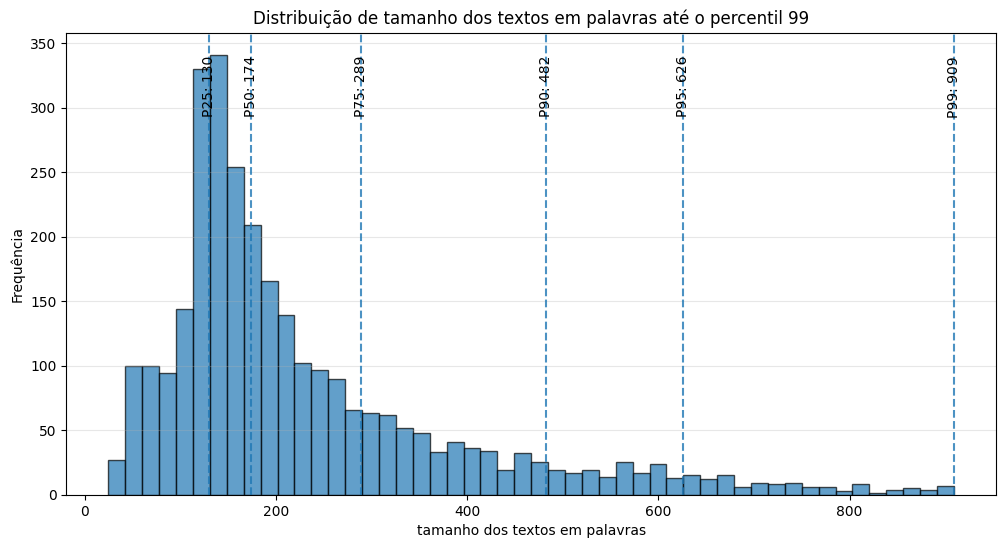

In [13]:
plotar_histograma_com_percentis(
    df_reviews["length"],
    nome="tamanho dos textos em palavras",
    limite_percentil=0.99,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=False,
    casas_decimais=0
)


A seguir, verificamos a quantidade de palavras de nossas amostras e a quantidade de tokens (palavras distintas) da amostra completa.

In [14]:
token_counts = Counter(
    token
    for comment in df_reviews["reviews"]
    for token in comment.split()
)
# Ordena os tokens do mais frequente para o menos frequente
frequencias_ordenadas = sorted(token_counts.values(), reverse=True)

total_ocorrencias = sum(frequencias_ordenadas)
total_tokens_unicos = len(frequencias_ordenadas)

print(f"Total de ocorrências de palavras: {br_number(total_ocorrencias)}")
print(f"Quantidade de palavras distintas: {br_number(total_tokens_unicos)}")

Total de ocorrências de palavras: 717.333
Quantidade de palavras distintas: 31.426


Vamos gerar um gráfico com a cobertura de tokens para um determinado `VOCAB_SIZE` para auxiliar na escolha do melhor valor. Para tanto vamos calcular a cobertura para cada uma das opções a seguir.

In [15]:
vocab_sizes = [
     2_500,
     5_000,
     7_500,
    10_000,
    12_500,
    15_000
]

In [16]:
resultados_vocabulario = []

for vocab_size in vocab_sizes:
    tamanho_efetivo = min(vocab_size, total_tokens_unicos)

    ocorrencias_cobertas = sum(frequencias_ordenadas[:tamanho_efetivo])
    ocorrencias_oov = total_ocorrencias - ocorrencias_cobertas

    resultados_vocabulario.append({
        "VOCAB_SIZE": vocab_size,
        "palavras incluídas": tamanho_efetivo,
        "ocorrências cobertas": ocorrencias_cobertas,
        "cobertura (%)": ocorrencias_cobertas / total_ocorrencias * 100,
        "ocorrências OOV": ocorrencias_oov,
        "OOV (%)": ocorrencias_oov / total_ocorrencias * 100
    })

df_vocabulario = pd.DataFrame(resultados_vocabulario)

df_vocabulario.style.format({
    "VOCAB_SIZE": "{:,.0f}",
    "palavras incluídas": "{:,.0f}",
    "ocorrências cobertas": "{:,.0f}",
    "cobertura (%)": "{:.2f}",
    "ocorrências OOV": "{:,.0f}",
    "OOV (%)": "{:.2f}"
})

,VOCAB_SIZE,palavras incluídas,ocorrências cobertas,cobertura (%),ocorrências OOV,OOV (%)
0,"2,500","2,500","611,584",85.26,"105,749",14.74
1,"5,000","5,000","651,045",90.76,"66,288",9.24
2,"7,500","7,500","670,765",93.51,"46,568",6.49
3,"10,000","10,000","683,058",95.22,"34,275",4.78
4,"12,500","12,500","691,536",96.40,"25,797",3.60
5,"15,000","15,000","697,584",97.25,"19,749",2.75


Por fim criamos um gráfico de VOCAB_SIZE X Cobertura de tokens do vocabulário.

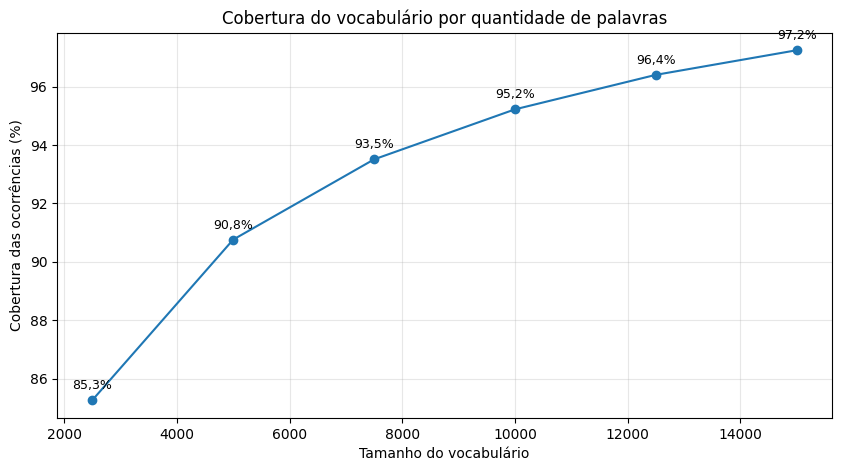

In [17]:
def plotar_cobertura_vocabulario():
    plt.figure(figsize=(10, 5))

    plt.plot(
        df_vocabulario["VOCAB_SIZE"],
        df_vocabulario["cobertura (%)"],
        marker="o"
    )

    for x, y in zip(
        df_vocabulario["VOCAB_SIZE"],
        df_vocabulario["cobertura (%)"]
    ):
        plt.annotate(
            f"{y:.1f}%".replace(".", ","),
            xy=(x, y),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

    plt.title("Cobertura do vocabulário por quantidade de palavras")
    plt.xlabel("Tamanho do vocabulário")
    plt.ylabel("Cobertura das ocorrências (%)")
    plt.grid(True, alpha=0.3)

    plt.show()

plotar_cobertura_vocabulario()

Pelo gráfico podemos observar que `VOCAB_SIZE = 5_000` nos permite alcançar cobertura de 90% das palavras da nossa amostra. Os demais tokens serão identificados todos como `[UNK]`, o token pré-definido para representar palavras desconhecidas.

In [18]:
VOCAB_SIZE = 5_000

##### Dividindo os conjuntos de treino, validação e testes e levantando informações para preparação das amostras de sequencias

Nos passos seguintes, vamos gerar, a partir de cada review, sequências de tokens com tamanho máximo igual a 16. Cada sequência será utilizada como entrada para que o modelo aprenda a prever o token seguinte.

Entretanto, antes de gerar essas sequências, é necessário separar os conjuntos de treinamento e teste. Essa separação deve ser realizada no nível das reviews completas, e não no nível das sequências geradas. Caso contrário, trechos muito semelhantes de uma mesma review podem aparecer simultaneamente nos dois conjuntos. Nessa situação, o modelo seria avaliado com sequências muito próximas daquelas utilizadas durante o treinamento, produzindo métricas excessivamente otimistas.

O vocabulário também deve ser construído utilizando apenas as reviews do conjunto de treinamento. Dessa forma, informações específicas dos textos reservados para teste não influenciam a preparação do modelo. Palavras que aparecem apenas no conjunto de teste serão representadas pelo token `[UNK]`.

Como as reviews possuem comprimentos variados, cada uma delas gera uma quantidade diferente de sequências. Portanto, uma separação contendo 80% das reviews para treinamento e 20% para teste não necessariamente produzirá a mesma proporção entre as sequências geradas. Após a divisão, é necessário verificar a quantidade de amostras resultante em cada conjunto e avaliar se a proporção permanece adequada. Dado que queremos janelas deslizantes de *até* 16 tokens, admitindo janelas com menos tokens (preenchidos por padding), podemos facilmente calcular o numero de sequencias geradas a partir de cada documento como sendo: `sequence_count = length - 1`. Vamos então adicionar essa coluna no `df_reviews`

Por fim vamos verificar se, após a separação dos conjuntos de treino e validação, a proporção de sequencias a serem geradas permanece aceitável. Certamente a distribuição se modificará, mas esperamos que ela se mantenha com uma proporção aceitável para o objetivo de treino e validação do modelo.

In [19]:
df_reviews["sequence_count"] = (df_reviews["length"] - 1).clip(lower=0)

df_reviews["sequence_count"].describe()

count    3000.000000
mean      238.111000
std       183.397587
min        24.000000
25%       129.000000
50%       173.000000
75%       288.000000
max      2482.000000
Name: sequence_count, dtype: float64

In [20]:
df_test = df_test[["reviews"]].copy() # copiamos somente a coluna reviews do dataframe original

df_test["reviews"] = ( # aplicamos o pré-processamento nas reviews do conjunto de teste
    Preprocessor(
        tf.constant(
            df_test["reviews"].tolist()
        )
    )
    .numpy()
    .astype(str)
)

df_test["length"] = ( # calculamos o número de tokens de cada review
    df_test["reviews"]
    .str.split()
    .str.len()
)

df_test["sequence_count"] = ( # calculamos o número de sequências de cada review
    df_test["length"] - 1
).clip(lower=0)

df_train, df_val = train_test_split( # separamos o conjunto de treino e validação
    df_reviews,
    test_size=0.20,
    random_state=RANDOM_STATE
)

E a seguir verificamos a proporção dos tres conjuntos em termos de quantidade de reviews e quantidades de sequencias. Podemos observar que existe uma pequena diferença no balanceamos entre reviews e sequencias, o que é normal e esperado. Como a diferença apresentada entre ambos é pequena, podemos manter a separação dos conjuntos realizada.

In [21]:
datasets = {
    "Treino": df_train,
    "Validação": df_val,
    "Teste": df_test,
}

total_reviews = len(df_reviews)
total_sequences = df_reviews["sequence_count"].sum()

print(f"Total de reviews:    {total_reviews:,}")
print(f"Total de sequências: {total_sequences:,}")

for name, dataset in datasets.items():
    review_count = len(dataset)
    sequence_count = dataset["sequence_count"].sum()

    print(f"\n{name}")
    print(
        f"Reviews:    {review_count:,} "
        f"({review_count / total_reviews:.2%})"
    )
    print(
        f"Sequências: {sequence_count:,} "
        f"({sequence_count / total_sequences:.2%})"
    )
    print(dataset["sequence_count"].describe())

Total de reviews:    3,000
Total de sequências: 714,333

Treino
Reviews:    2,400 (80.00%)
Sequências: 579,767 (81.16%)
count    2400.000000
mean      241.569583
std       187.418938
min        24.000000
25%       129.000000
50%       176.000000
75%       293.000000
max      2482.000000
Name: sequence_count, dtype: float64

Validação
Reviews:    600 (20.00%)
Sequências: 134,566 (18.84%)
count     600.000000
mean      224.276667
std       165.767875
min        30.000000
25%       126.000000
50%       164.500000
75%       264.250000
max      1003.000000
Name: sequence_count, dtype: float64

Teste
Reviews:    500 (16.67%)
Sequências: 115,241 (16.13%)
count     500.000000
mean      230.482000
std       177.759271
min        24.000000
25%       124.000000
50%       166.500000
75%       278.000000
max      1075.000000
Name: sequence_count, dtype: float64


### **2º Passo:**
<font size=3>

- Realize a indexação dos textos, utilizando a a função [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/):
    - Considere, *inicialmente*, um vocabulário de tamanho 5000;
    - Faça a indexação sem preenchimento (*padding*). Para isso, defina as variáveis `output_sequence_length = None` e `ragged = True`.
    <br>

- Defina a lista de vocabulário por meio do método `get_vocabulary` do objeto de `TextVectorization`;

- Defina os dados indexados com o nome `token_ids`.


Pudemos observar no item 1 que o tamanho de `VOCAB_SIZE = 5_000` implica uma cobertura de cerca de 90% dos tokens das amostras que utilizaremos no treinamento. Vamos inicialmente criar três lista contendo os textos de cada conjunto: treinamento, validação e teste.

In [22]:
texts_train = df_train["reviews"].tolist()
texts_val = df_val["reviews"].tolist()
texts_test = df_test["reviews"].tolist()

A seguir vamos criar nosso vetorizador de textos exclusivamente a partir dos textos do conjunto de treino.

In [23]:
vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    standardize=Preprocessor,
    output_sequence_length=None,
    ragged=True,
    output_mode="int",
)

# Aprende o vocabulário exclusivamente com os textos de treino.
vectorizer.adapt(texts_train)

vocab = np.array(
    vectorizer.get_vocabulary()
)

vocab[:10]

array(['', '[UNK]', 'the', 'and', 'a', 'of', 'to', 'is', 'it', 'in'],
      dtype='<U16')

### **3º Passo:**
<font size=3>

- O *array* `token_ids` é formado por vetores indexados de tamanhos distintos. Mas, agora, iremos decompor cada vetor, *e.g.* $[2,\, 5,\, 3,\, 1,\, 8]$, como sequências do "próximo *token*":
$$
    [2,\, 5],\, [2,\, 5,\, 3],\, [2,\, 5,\, 3,\, 1],\, [2,\, 5,\, 3,\, 1,\, 8]
$$

- Assim, defina uma lista `sequences` que irá capturar as sequências de **todos** os vetores;

- Utilize a função [`pad_sequences`]() para preencher as sequências da esqueda para a direira:
$$
    [ 0,\, 0,\, 0,\, 2,\, 5],\, [0,\, 0,\, 2,\, 5,\, 3],\, [0,\, 2,\, 5,\, 3,\, 1],\, [2,\, 5,\, 3,\, 1,\, 8]
$$
    - Defina o tamanho da entrada da rede `max_len = 16`;
    - Defina as variáveis da função `maxlen = max_len+1` e `padding = "pre"`.
  

#### Resolucao item 3

Antes de proceder com a resolução do item, é importante comentar e explicar as modificações que vamos implementar na sua proposição.

O problema com a abordagem de padding a esquerda sugerida é que ela impede a utilizacao de otimizações necessárias para processar corretamente o padding pela rede neural. Tentamos inicialmente utilizar a abordagem sugerida, porém o resultado gerou treinamento lento por não permitir utilizar algumas das possibilidades de otimização oferecidas pelo Keras. Em específico, no layer de Embeddings, necessitamos utilizar mask_zero=True para que o modelo ignore os paddings que vamos produzir. Porém, essa opção exige necessariamente padding a direita. Se habilitamos essa opção e utilizamos padding a esquerda, o Keras gera erro e não permite o processamento. E gerar os embeddings sem essa opção gera um modelo de pior qualidade.

Então vamos adotar uma abordagem inversa: queremos que as frases sofram padding à direita para permitir o uso da opção `mask_zero=True`. 
Com isso, vamos aproveitar e montar os arrays X e y numa unica etapa.

Considerando o exemplo dado no enunciado do exercício, as sequências de "próximo *token*" que adotaremos tem a seguinte forma:

Frase completa: $[2,\, 5,\, 3,\, 1,\, 8]$

Geração de sequências

| Id | Sequência (X)                                                                    | Próximo Token (y) |
| -- | -------------------------------------------------------------------------------- | ----------------- |
| 01 | $[2,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0]$ | $[5]$             |
| 02 | $[2,\, 5,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0]$ | $[3]$             |
| 03 | $[2,\, 5,\, 3,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0]$ | $[1]$             |
| 04 | $[2,\, 5,\, 3,\, 1,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0,\, 0]$ | $[8]$             |


É importante a notar também que as frases possuem tamanhos variáveis, como foi mostrado nos passos anteriores. Como vamos trabalhar com uma janela de contexto de 16 tokens, montar sequencias maiores que 16 tokens é disperdicio de tempo e espaço. Vamos trabalhar então com uma janela deslizante de até 16 tokens sobre cada texto, descartando o primeiro token e produzindo um deslocamento à esquerda dos demais tokens para criar espaço para um eventual novo token.

Outro ponto fundamental que foi notado no momento posterior de modelagem e avaliação dos resultados: treinar o modelo com sequências cuja previsão de próximo token fosse igual ao token desconhecido (`[UNK]`) não nos ajudaria a gerar as tres frases com conteúdo semanticamente significativo. Portanto, durante o processo de geração das sequencias definido a seguir, aquelas sequencias cujo próximo token previsto fossem iguais ao token `[UNK]` foram explicitamente ignoradas e excluídas da saída.

Por fim, criamos uma função que nos permitisse normalizar qualquer conjunto de textos, dado o vectorizer, os textos, o tamanho da janela e deixamos parametrizável se o token desconhecido deveria ser ignorado no target. Assim, foi possível aplicar sistematicamente ao conjunto de treino, validação e testes, bem como verificar o desempenho do modelo em relação a manter ou ignorar as sequências cuja previsão fosse `[UNK]`.

In [24]:
def gerar_sequencias(
    texts,
    vectorizer,
    max_len,
    ignorar_target_unk=True
):
    token_ids = vectorizer(texts).to_list()

    contexts = []
    targets = []

    for document_ids in token_ids:
        for target_position in range(1, len(document_ids)):
            target = document_ids[target_position]

            # Ignora sequências cujo próximo token previsto seja o token desconhecido
            if ignorar_target_unk and target == 1:
                continue

            start_position = max(
                0,
                target_position - max_len
            )

            contexts.append(
                document_ids[start_position:target_position]
            )

            targets.append(
                target
            )

    X = pad_sequences(
        contexts,
        maxlen=max_len,
        padding="post",
        truncating="pre"
    )

    y = np.array(
        targets,
        dtype=np.int32
    )

    return X, y

### **4º Passo:**
<font size=3>

- Agora, iremos definir as variáveis $X$ e $y$ do modelo:
    - Onde $X$ serão as sequências até o **penúltimo elemento**, *e.g.*, $[ 0,\, 0,\, 0,\, 2]$;
    - e $y$ serão o **último elemento** das sequências, *e.g.*, $[5]$.
    <br>

- Verifique se $X$ apresenta dimensão `max_len`;


#### Resolução do item 4

Produzimos a criação dos conjuntos `X` e `y` no item anterior. E conforme explicado anteriormente, produzimos os conjuntos com padding à direita ao invés do proposto. A justificativa completa e detalhada da motivação que levou a trocar a abordagem sugerida está explicada na resolução do item 3.

A seguir executamos a função `gerar_sequencias` criada no item 3 para os conjuntos de treino, validação e testes.

In [25]:
X_train, y_train = gerar_sequencias(
    texts_train,
    vectorizer,
    MAX_LEN
)

X_val, y_val = gerar_sequencias(
    texts_val,
    vectorizer,
    MAX_LEN
)

X_test, y_test = gerar_sequencias(
    texts_test,
    vectorizer,
    MAX_LEN
)

Em seguida mostramos o formato dos arrays de dados gerados.

In [26]:
print("Treino:   ", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:    ", X_test.shape, y_test.shape)

Treino:    (526774, 16) (526774,)
Validação: (120810, 16) (120810,)
Teste:     (103544, 16) (103544,)


E mostramos 8 exemplos de sequencias geradas para o conjunto de treino.

In [27]:

print(X_train.shape)
print(y_train.shape)
n = 8
print(X_train[:n])
print(y_train[:n])

(526774, 16)
(526774,)
[[ 10   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 10  14   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 10  14 163   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 10  14 163 153   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 10  14 163 153 152   0   0   0   0   0   0   0   0   0   0   0]
 [ 10  14 163 153 152  55   0   0   0   0   0   0   0   0   0   0]
 [ 10  14 163 153 152  55  11   0   0   0   0   0   0   0   0   0]
 [ 10  14 163 153 152  55  11 118   0   0   0   0   0   0   0   0]]
[ 14 163 153 152  55  11 118  14]


Por fim queremos deixar registrado a função auxiliar que foi utilizada para identifica os alvos com predição de token desconhecido. No final os tres conjuntos ficaram sem previsão de targets `[UNK]`, mas sem o auxílio dessa função não seria possível verificar que nossa geração de sequências estava correta.

In [28]:
UNK_ID = 1

def analisar_targets(y, nome):
    total = len(y)
    unk_count = np.sum(y == UNK_ID)

    print(nome)
    print(f"Total de sequências: {total:,}")
    print(f"Targets [UNK]:       {unk_count:,}")
    print(f"Proporção [UNK]:     {unk_count / total:.2%}")
    print()


analisar_targets(y_train, "Treino")
analisar_targets(y_val, "Validação")
analisar_targets(y_test, "Teste")

Treino
Total de sequências: 526,774
Targets [UNK]:       0
Proporção [UNK]:     0.00%

Validação
Total de sequências: 120,810
Targets [UNK]:       0
Proporção [UNK]:     0.00%

Teste
Total de sequências: 103,544
Targets [UNK]:       0
Proporção [UNK]:     0.00%



### **5º Passo:**
<font size=3>

- Desenvolva a rede neural:
    - Já sabemos do tamanho da camada de entrada, mas a **camada de saída** deverá *retornar qual o próximo token mais provável da lista de vocabulário*.
    - **Observação:** aqui, talvez, você ache incompatível a variável algo $y$ com a camada de saída, mas iremos dar um jeito na função de custo, a seguir.
      

#### Resolução Item 5

Neste exercício decidimos adotar uma abordagem menos sistemática e mais exploratória que aquelas que adotamos nas atividades anteriores. Ao invés de trabalhar a partir de `GridSearch` e `RandomSearch` com espaços de busca potencialmente grandes, preferimos uma abordagem investigativa mais pequena, realizando modificações na modelagem um passo por vez. A cada nova modificação, avaliamos a solução comparando resultados quantitativos (na forma de função de perda e acurácia) e qualitativos (na forma de avaliação das frases geradas a partir do modelo). O principal motivador para modificar a abordagem foi que observamos que os treinamentos necessários no nosso contexto são potencialmente maiores e mais lentos que os existentes até então. Todo esse processo exploratório e iterativo será explicado no final da atividade.

No processo de modelagem chegamos a conclusão que seria benéfico para nossa atividade utilizar os embeddings pré-treinados do GloVe para atingir o objetivo de gerar 3 palavras em sequencia com significado. O processo que nos levou a tal conclusão será explicado no relatório do final da atividade. Também durante esse processo, notamos que aumentar o tamanho do embedding gerava resultados melhores. Porém, percebemos também que valeria mais a pena trabalhar a partir de um conjunto de embeddings pré-treinados. Como temos disponível os embeddings do GloVe com 100 dimensões, abandonamos os experimentos com embeddings diferentes de 100. Porém preservamos as principais características da modelagem que nos gerou melhor resultado.

In [29]:
EMBED_DIM = 100 # para fazer transfer learning com o GloVe

Carregamos o glove a partir dos dados disponíveis localmente:

In [30]:
GLOVE_PATH = "./dataset/glove.6B.100d.txt"

embeddings_index = {}

with open(GLOVE_PATH, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print(f"Vetores GloVe carregados: {len(embeddings_index)}")


Vetores GloVe carregados: 400000


A seguir montamos nossa matrix de embeddings a partir de uma inicialização aleatória. Isso nos permitirá tratar os tokens que não existem no GloVe de forma aleatória. Num primeiro momento deixamos os tokens zerados. Apesar da frequência baixa, entendemos que não permitir que o modelo gere diferenciação entre os tokens inexistentes no glove, ou pior, que eles sejam confundidos com padding, é mais prejudicial ao desempenho do modelo como um todo que deixar os tokens inexistentes com valores aleatórios.

Também aproveitamos para coletar algumas métricas para avaliar se a cobertura dos embeddings existentes no GloVe em relação aos nossos tokens poderia ser um problema. 

In [31]:
vocab = vectorizer.get_vocabulary()
num_tokens = len(vocab)

# vetor de inicialização aleatório para permitir que tokens ausentes sejam representados sem repetição de valores
embedding_matrix = np.random.normal(
    loc=0.0,
    scale=0.05,
    size=(num_tokens, EMBED_DIM)
).astype("float32")

# contadores para avaliar a cobertura dos embeddings existentes no GloVe em relação aos nossos tokens
hits = 0
misses = 0
missing_tokens = []

# para cada token, verificamos se ele existe no GloVe
for token_id, word in enumerate(vocab):
    embedding_vector = embeddings_index.get(word)

    if embedding_vector is not None:
        # se o token existe no GloVe, copiamos o vetor para a matrix de embeddings
        embedding_matrix[token_id] = embedding_vector
        hits += 1
    else:
        # se o token não existe no GloVe, adicionamos ele a lista de tokens ausentes
        misses += 1

        missing_tokens.append(
            (token_id, word)
        )

# Garantindo que somente o padding deve possuir vetor integralmente zerado.
embedding_matrix[0] = np.zeros(
    EMBED_DIM,
    dtype="float32"
)

print(f"Matrix de embeddings: {embedding_matrix.shape}")


Matrix de embeddings: (5000, 100)


Por fim contamos e verificamos quais os tokens não foram encontrados no GloVe para uma avaliação qualitativa. Foi essa verificação que nos permitiu identificar que a qualidade do nosso pré processamento deveria melhorar, considerando as contrações específicas mencionadas anteriormente.

In [32]:
# Conta as ocorrências reais nos textos utilizados no treino.
token_ids_train = (
    vectorizer(texts_train)
    .flat_values
    .numpy()
)

frequencias = Counter(
    token_ids_train
)

print(f"Tokens encontrados no GloVe: {hits}")
print(f"Tokens não encontrados.....: {misses}")
print(f"Cobertura..................: {hits / num_tokens:.2%}")

print("\nTokens ausentes no GloVe:")
print(f"{'ID':>5}  {'TOKEN':<25} {'FREQUÊNCIA':>10}")
print("-" * 44)

for token_id, word in sorted(
    missing_tokens,
    key=lambda item: frequencias[item[0]],
    reverse=True
):
    token_exibido = (
        "<PADDING>"
        if token_id == 0
        else word
    )

    print(
        f"{token_id:>5}  "
        f"{token_exibido:<25} "
        f"{frequencias[token_id]:>10,}"
    )

Tokens encontrados no GloVe: 4994
Tokens não encontrados.....: 6
Cobertura..................: 99.88%

Tokens ausentes no GloVe:
   ID  TOKEN                     FREQUÊNCIA
--------------------------------------------
    1  [UNK]                         53,144
 3836  interferencia                     12
 4690  shepitko                           9
 4748  otoole                             9
 4823  hynkel                             9
    0  <PADDING>                          0


O modelo a seguir foi adaptado e readaptado a cada nova modificação da arquitetura. A cada nova iteração, as células eram limpas, o ambiente reiniciado e a nova execução era realizada.

In [33]:
x_in = layers.Input(
    shape=(MAX_LEN,), # entrada com o tamanho da janela MAX_LEN
    dtype=tf.int32, 
    name="input")
#x = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="embedding")(x_in)
x = layers.Embedding(
    input_dim=embedding_matrix.shape[0], # número de tokens
    output_dim=embedding_matrix.shape[1], # dimensão dos embeddings
    weights=[embedding_matrix], # inicialização com o GloVe
    mask_zero=True, # para que o modelo ignore os tokens de padding
    trainable=False, # para que os embeddings não sejam atualizados durante o treinamento
    name="glove_embedding"
)(x_in)
x = layers.LSTM(256, return_sequences=False, name="lstm")(x) # 256 unidades LSTM nos gerou melhores resultados que 128 ou outras opções menores
#x = layers.LSTM(128, return_sequences=False, name="lstm")(x)
x = layers.Dropout(0.2, name="dropout")(x) # dropout para evitar overfitting
#x = layers.Dense(256, activation="relu", name="dense1")(x) # não gerou melhores resultados que a arquitetura sem essa camada
#x = layers.Dense(1600, activation="relu", name="dense3")(x) # não gerou melhores resultados que a arquitetura sem essa camada
x_out = layers.Dense(VOCAB_SIZE, activation="softmax", name="output")(x) # saída com o tamanho do vocabulário e softmax para gerar probabilidades

model = Model(x_in, x_out)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 16)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ glove_embedding     │ (None, 16, 100)   │    500,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 16)        │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    365,568 │ glove_embedding[… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 5000)      │  1,285,000 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,150,568 (8.20 MB)

 Trainable params: 1,650,568 (6.30 MB)

 Non-trainable params: 500,000 (1.91 MB)

### **6º Passo:**
<font size=3>

- Compile o modelo com:
    - Otimizador `Adam`;
    - Para lidar com **saídas probabilística** e **variável alvo categórica**, utilizaremos a **função de custo** [`sparse_categorical_crossentropy`](https://keras.io/api/losses/probabilistic_losses/#sparsecategoricalcrossentropy-class);
    - Métrica [`SparseTopKCategoricalAccuracy`](https://www.tensorflow.org/api_docs/python/tf/keras/metrics/SparseTopKCategoricalAccuracy) para pegar os $k=5$ maiores valores da camada de saída.


#### Resolução item 6

Durante o processo de modelagem exploratório iterativo tivemos algumas versões diferentes de configurações de otimizadores, learning rate decay e de early stopping. A função a seguir representa a versão final que foi utilizada, com early stopping com patience = 4 épocas, e redução de learning rate por um fator de 0.5 com minimo de lr = 1e-5 se não houver melhora por 2 épocas seguidas.

In [34]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

Da mesma forma, o learning rate inicial que produziu os melhores resultados foi de `lr = 3e-4`. A seguir compilamos o modelo utilizando as métricas sugeridas pelo exercício e as configurações mencionadas anteriormente.

In [35]:

model.compile(
    optimizer=Adam(
        learning_rate=3e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)


### **7º Passo:**
<font size=3>

- Realize o **treinamento validativo** do modelo com:
    - 15 épocas (inicialmente);
    - `batch_size` > 100;
    - `validation_split = 0.2`.
      

#### Resolução do item 7

A seguir executamos o treinamento. Ao longo da exploração realizada chegamos na conclusão que utilizar até 40 épocas para treinamento não seria um problema, considerando que temos o early stopping configurado, evitando o disperdicio de tempo. Também testamos alguns valores distintos de batch_size e chegamos no valor `batch_size=256` como nossa melhor escolha.

In [36]:
history = model.fit(
    x=X_train,
    y=y_train,
    epochs=40,
    batch_size=256,
    validation_data=(
        X_val,
        y_val
    ),
    callbacks=callbacks
)

Epoch 1/40


2026-06-15 18:07:45.620502: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2058/2058 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 6.1884 - top_5_accuracy: 0.2069 - val_loss: 5.8745 - val_top_5_accuracy: 0.2470 - learning_rate: 3.0000e-04
Epoch 2/40
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - loss: 5.8171 - top_5_accuracy: 0.2553 - val_loss: 5.6487 - val_top_5_accuracy: 0.2748 - learning_rate: 3.0000e-04
Epoch 3/40
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 5.6308 - top_5_accuracy: 0.2764 - val_loss: 5.5151 - val_top_5_accuracy: 0.2940 - learning_rate: 3.0000e-04
Epoch 4/40
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - loss: 5.5054 - top_5_accuracy: 0.2899 - val_loss: 5.4301 - val_top_5_accuracy: 0.3047 - learning_rate: 3.0000e-04
Epoch 5/40
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - loss: 5.4139 - top_5_accuracy: 0.2984 - val_loss: 5.3732 - val_top_5_accuracy: 0.3113 - learning_rate: 3.0000e-04
Epoch 6/40
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 5.3410 - top_5_accuracy: 0.3052 - val_loss: 5.3214 - val_top_5_accuracy: 0.3181 - learn

#### Funções auxiliares para análise da qualidade do modelo

Para permitir análise exploratória e iterativa, sentimos a necessidade de fazer algumas verificações sobre os dados. 

A primeira dessas verificações é ter idéia de quais os tokens previstos eram mais frequentes nos conjuntos de treino e validação, independentemente de qualquer treinamento.
Em outras palavras, quais os tokens aparecem mais vezes nas variáveis `y_train` e `y_val`. Isso nos permite ter uma idéia do que seria um modelo de previsão baseado somente na frequência dos dados.

In [37]:
def exibir_targets_mais_frequentes(y, vocab, quantidade=10):
    ids, counts = np.unique(
        y,
        return_counts=True
    )

    ordem = np.argsort(
        counts
    )[::-1]

    total = len(y)

    for token_id, count in zip(
        ids[ordem][:quantidade],
        counts[ordem][:quantidade]
    ):
        print(
            f"{token_id:4d} "
            f"{vocab[token_id]:15s} "
            f"{count:6d} "
            f"{count / total:7.2%}"
        )


print("Conjunto de Treino")
exibir_targets_mais_frequentes(
    y_train,
    vocab
)

print("\nConjunto de Validação")
exibir_targets_mais_frequentes(
    y_val,
    vocab
)

Conjunto de Treino
   2 the              33130   6.29%
   3 and              16302   3.09%
   4 a                15943   3.03%
   5 of               14441   2.74%
   6 to               13336   2.53%
   7 is               13122   2.49%
   8 it                9430   1.79%
   9 in                9333   1.77%
  10 i                 8081   1.53%
  12 that              7103   1.35%

Conjunto de Validação
   2 the               7826   6.48%
   4 a                 3823   3.16%
   3 and               3742   3.10%
   5 of                3302   2.73%
   6 to                3220   2.67%
   7 is                3058   2.53%
   8 it                2146   1.78%
   9 in                2123   1.76%
  10 i                 1884   1.56%
  12 that              1679   1.39%


Em seguida, considerando que nossa métrica de acurácia considera os top 5 elementos da curva de probabilidade, queremos determinar o que seria um baseline mínimo de desempenho para o nosso modelo. Um modelo que somente prediz as top 5 palavras mais frequentes, quanto de acurácia obteria? Quais os tokens ele iria prever? O trecho de codigo a seguir responde isso: nosso modelo "ingênuo" deveria obter um baseline de pelo menos aproximadamente 18% de acurácia top 5.

In [38]:
def calcular_baseline_top_k(
    y_train,
    y_eval,
    k=5
):
    ids, counts = np.unique(
        y_train,
        return_counts=True
    )

    top_k_ids = ids[
        np.argsort(counts)[-k:]
    ]

    accuracy = np.mean(
        np.isin(y_eval, top_k_ids)
    )

    return top_k_ids, accuracy


top_5_ids, baseline_val = calcular_baseline_top_k(
    y_train,
    y_val,
    k=5
)

print("Tokens previstos pelo baseline:")
for token_id in top_5_ids:
    print(
        token_id,
        repr(vocab[token_id])
    )

print(
    f"\nBaseline top-5 na validação: "
    f"{baseline_val:.2%}"
)

Tokens previstos pelo baseline:
6 np.str_('to')
5 np.str_('of')
4 np.str_('a')
3 np.str_('and')
2 np.str_('the')

Baseline top-5 na validação: 18.14%


A seguinte função tem por objetivo comparar a probabilidade da próxima palavra gerada a partir de uma frase com a frequência global da respectiva palavra. Nossa hipótese com essa comparação é que, se o modelo está aprendendo adequadamento o contexto das palavras, a probabilidade da maioria das palavras geradas deveria divergir significativamente da frequência global da respectiva palavra.

In [39]:
def comparar_contexto_com_frequencia_global(
    modelo,
    texto,
    vectorizer,
    max_len,
    vocab,
    y_train,
    k=15
):
    ids = vectorizer([texto]).to_list()[0]

    x = pad_sequences(
        [ids[-max_len:]],
        maxlen=max_len,
        padding="post",
        truncating="pre"
    )

    probs = modelo.predict(
        x,
        verbose=0
    )[0].copy()

    probs[0] = 0  # padding
    probs[1] = 0  # [UNK]

    global_counts = np.bincount(
        y_train,
        minlength=len(vocab)
    )

    global_probs = (
        global_counts / global_counts.sum()
    )

    top_ids = np.argsort(
        probs
    )[-k:][::-1]

    print(f"\nContexto: {texto}\n")
    print(
        f"{'token':15s} "
        f"{'contexto':>10s} "
        f"{'global':>10s} "
        f"{'razão':>8s}"
    )

    for token_id in top_ids:
        contextual = probs[token_id]
        global_prob = global_probs[token_id]

        razao = (
            contextual / global_prob
            if global_prob > 0
            else np.inf
        )

        print(
            f"{vocab[token_id]:15s} "
            f"{contextual:9.3%} "
            f"{global_prob:9.3%} "
            f"{razao:8.2f}"
        )

#### Colocando o modelo a prova

Embora o item 9 solicite explicitamente criar a função geradora dos textos, entendemos que devemos antecipar essa definição para permitir avaliar a qualidade do modelo, não apenas de forma quantitativa, mas também de forma qualitativa, na forma de verificação de coerencia das frases geradas. Portanto, definimos a seguir algumas frases que vamos utilizar para executar o processo de geração de palavras. E na sequência definimos duas estratégias distintas para gerar as palavras.

In [45]:
# As frases de teste foram escolhidas para permitir uma avaliação mais ampla do modelo.
frases_teste = [
    "the movie was",
    "the acting was",
    "the soundtrack was",
    "what i liked the most was",
    "the ending of the film was",
]

In [46]:
for frase_original in frases_teste:

    comparar_contexto_com_frequencia_global(
        modelo=model,
        texto=frase_original,
        vectorizer=vectorizer,
        max_len=MAX_LEN,
        vocab=vocab,
        y_train=y_train,
        k=10
    )


Contexto: the movie was

token             contexto     global    razão
a                  6.602%    3.027%     2.18
made               2.884%    0.157%    18.37
the                2.669%    6.289%     0.42
by                 2.496%    0.427%     5.84
not                2.411%    1.188%     2.03
great              2.002%    0.171%    11.72
very               1.954%    0.244%     8.01
written            1.768%    0.030%    58.20
so                 1.541%    0.399%     3.86
in                 1.497%    1.772%     0.84

Contexto: the acting was

token             contexto     global    razão
made               3.819%    0.157%    24.33
written            3.424%    0.030%   112.73
a                  3.224%    3.027%     1.07
great              3.079%    0.171%    18.02
very               2.699%    0.244%    11.06
not                2.434%    1.188%     2.05
terrible           1.879%    0.031%    60.71
terrific           1.314%    0.008%   157.30
done               1.276%    0.056%    22.8

##### Gerador de Palavras Guloso

Primeiro definimos uma função de geração de palavras conforme a especificação da atividade. Geramos n palavras de forma iterativa, tomando cada palavra escolhida e inserindo o token gerado no final da frase e voltando a iterar. 

In [47]:
def gerar_proximas_palavras(
    modelo,
    texto,
    vectorizer,
    max_len,
    vocab,
    n=3
):
    """
    Gera as próximas palavras de forma determinística,
    selecionando sempre o token mais provável.
    """

    # Aplica o mesmo vectorizer utilizado durante o treinamento.
    ids = (
        vectorizer([texto])
        .to_list()[0]
    )

    novas = []

    for _ in range(n):
        # Preserva apenas os tokens mais recentes e aplica padding à direita.
        x = pad_sequences(
            [ids[-max_len:]],
            maxlen=max_len,
            padding="post",
            truncating="pre"
        )

        # Calcula a distribuição de probabilidades da próxima palavra.
        probs = modelo.predict(
            x,
            verbose=0
        )[0].copy()

        # Bloqueia tokens que não devem ser gerados.
        probs[0] = 0  # padding
        probs[1] = 0  # [UNK]

        # Seleciona a palavra mais provável.
        next_id = int(
            np.argmax(probs)
        )

        ids.append(next_id)
        novas.append(
            vocab[next_id]
        )

    return novas

##### Utilizando o gerador guloso

In [48]:
for frase_original in frases_teste:
    novas = gerar_proximas_palavras(
        modelo=model,
        texto=frase_original,
        vectorizer=vectorizer,
        max_len=MAX_LEN,
        vocab=vocab,
        n=8
    )

    frase_gerada = (
        frase_original
        + " "
        + " ".join(novas)
    )

    print(f"Frase original: {frase_original}")
    print(f"Frase gerada:   {frase_gerada}")
    print("-" * 100)

Frase original: the movie was
Frase gerada:   the movie was a good film i have seen the best
----------------------------------------------------------------------------------------------------
Frase original: the acting was
Frase gerada:   the acting was made in the first film of the film
----------------------------------------------------------------------------------------------------
Frase original: the soundtrack was
Frase gerada:   the soundtrack was a great film i have seen the best
----------------------------------------------------------------------------------------------------
Frase original: what i liked the most was
Frase gerada:   what i liked the most was a few years ago i am not a
----------------------------------------------------------------------------------------------------
Frase original: the ending of the film was
Frase gerada:   the ending of the film was a few of the best of the films
--------------------------------------------------------------------------

##### Gerador de Palavras Probabilístico

In [53]:
def escolher_proximo_token(
    probs,
    ids_gerados,
    top_k=10,
    temperature=0.8,
    repetition_penalty=0.5,
    ultimos_n=5
):
    probs = probs.copy()

    # Não gerar padding nem [UNK].
    probs[0] = 0
    probs[1] = 0

    # Penaliza palavras usadas recentemente.
    for token_id in ids_gerados[-ultimos_n:]:
        probs[token_id] *= repetition_penalty

    # Evita log(0).
    probs = np.maximum(
        probs,
        1e-12
    )

    logits = (
        np.log(probs)
        / temperature
    )

    top_ids = np.argsort(
        logits
    )[-top_k:]

    top_logits = logits[
        top_ids
    ]

    top_probs = np.exp(
        top_logits
        - np.max(top_logits)
    )

    top_probs = (
        top_probs
        / top_probs.sum()
    )

    return int(
        np.random.choice(
            top_ids,
            p=top_probs
        )
    )

In [50]:
def gerar_proximas_palavras_probabilistico(
    modelo,
    texto,
    vectorizer,
    max_len,
    vocab,
    n=3,
    top_k=10,
    temperature=0.8,
    repetition_penalty=0.5
):
    ids = (
        vectorizer([texto])
        .to_list()[0]
    )

    novas = []

    for _ in range(n):
        x = pad_sequences(
            [ids[-max_len:]],
            maxlen=max_len,
            padding="post",
            truncating="pre"
        )

        probs = modelo.predict(
            x,
            verbose=0
        )[0]

        next_id = escolher_proximo_token(
            probs=probs,
            ids_gerados=ids,
            top_k=top_k,
            temperature=temperature,
            repetition_penalty=repetition_penalty
        )

        ids.append(
            next_id
        )

        novas.append(
            vocab[next_id]
        )

    return novas

##### Utilizando o gerador probabilistico

Com o uso dessas funções foi possível observar se a melhora quantitativa do modelo, em termos de acurácia e função de perda, se traduziam em melhoras perceptíveis na geração dos textos.

In [54]:
for frase_original in frases_teste:
    print(f"Frase original: {frase_original}")

    for _ in range(9):
        novas = gerar_proximas_palavras_probabilistico(
            modelo=model,
            texto=frase_original,
            vectorizer=vectorizer,
            max_len=MAX_LEN,
            vocab=vocab,
            n=10,
            top_k=10,
            temperature=0.7,
            repetition_penalty=0.4
        )

        frase_gerada = (
            frase_original
            + " "
            + " ".join(novas)
        )

        print(
            f"Frase gerada:   "
            f"{frase_gerada}"
        )

    print("-" * 100)

Frase original: the movie was
Frase gerada:   the movie was by a big cast i saw it was a bit
Frase gerada:   the movie was very bad for the most times and i enjoyed a
Frase gerada:   the movie was not a bad film i saw this film and i
Frase gerada:   the movie was very difficult as the original character i watched it in
Frase gerada:   the movie was great by a good film and i have seen a
Frase gerada:   the movie was great i am surprised that it was not the worst
Frase gerada:   the movie was a few of the best movies i have watched in
Frase gerada:   the movie was a good film that has been done the movie was
Frase gerada:   the movie was so much than a low budget film but i saw
----------------------------------------------------------------------------------------------------
Frase original: the acting was
Frase gerada:   the acting was awful as a good movie it was the last of
Frase gerada:   the acting was a comedy was the funniest of this film was not
Frase gerada:   the acting was a

#### Uma última rodada de modelagem

Depois de executar o modelo exploratório iterativo mencionado anteriormente, ainda ficamos com algumas dúvidas quanto a como poderíamos melhorar o desempenho do modelo em termos de coerência das palavras geradas. Poderiamos investir em melhorar nossas funções geradoras de palavras, seja com estratégias probabilisticas mais sofisticadas, ou talvez com formas distintas de inferir a próxima palavra utilizando o modelo. Poderíamos também avanzar em processar mais exemplos de palavras, considerando que o maior ganho marginal que obtivemos no processo iterativo veio exclusivamente do aumento de 500 para 2000 textos treinados. Porém, o fato de haver incorporado os embeddings pré-treinados do GloVe, numa tentativa de realizar transfer learning para melhorar nosso resultado, nos deixou com as seguintes perguntas em mente:

- Será que aumentar ainda mais os dados de treinamento, de 2000 para 3000 reviews, produziria resultados cada vez melhores ou atingiriamos um limite de desempenho?
- Será que atualizar os pesos dos embeddings do GloVe durante o treinamento poderia produzir algum ajuste específico para o nosso contexto que os embeddings do GloVe puros não seriam capazes de reproduzir?
- Será que aumentar as camadas recorrentes produziriam melhores resultados?

Para responder a primeira pergunta, basta aumentar a quantidade de reviews e comparar os resultados obtidos. Já para as duas últimas perguntas, decidimos montar um pequeno `GridSearch` com tão somente duas variáveis, dois valores em cada variável, produzindo 4 novas execuções, já com 3.000 exemplos de reviews no conjunto de treinamento. Então testamos o seguinte:

- Liberar o treinamento dos pesos dos embeddings do GloVe: `[ True, False ]`
- Camadas Recorrentes: `[ 256, 384 ]`

A seguir implementamos a modelagem sugerida.

In [41]:
RESULTS_BASE_DIR = Path("atividade4-results")
GRID_SEARCH_RESULTS_DIR = RESULTS_BASE_DIR / "grid-search"
GRID_SEARCH_PROJECT_NAME = "lstm-glove-grid-v1"

GRID_SEARCH_OVERWRITE = True
GRID_SEARCH_EPOCHS = 40
GRID_SEARCH_BATCH_SIZE = 256

GRID_SEARCH_OBJECTIVE = "val_loss"
GRID_SEARCH_OBJECTIVE_DIRECTION = "min"

GRID_SEARCH_GLOVE_TRAINABLE_VALUES = [
    False,
    True
]

GRID_SEARCH_LSTM_UNITS_VALUES = [
    256,
    384
]

MODEL_DROPOUT = 0.2
MODEL_LEARNING_RATE = 3e-4
MODEL_TOP_K_ACCURACY = 5

EARLY_STOPPING_MONITOR = "val_loss"
EARLY_STOPPING_PATIENCE = 4

REDUCE_LR_MONITOR = "val_loss"
REDUCE_LR_FACTOR = 0.5
REDUCE_LR_PATIENCE = 2
REDUCE_LR_MIN = 1e-5

GRID_SEARCH_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [42]:
def construir_modelo_grid_search(hp):
    glove_trainable = hp.Choice(
        "glove_trainable",
        values=GRID_SEARCH_GLOVE_TRAINABLE_VALUES
    )

    lstm_units = hp.Choice(
        "lstm_units",
        values=GRID_SEARCH_LSTM_UNITS_VALUES
    )

    x_in = layers.Input(
        shape=(MAX_LEN,),
        dtype=tf.int32,
        name="input"
    )

    x = layers.Embedding(
        input_dim=embedding_matrix.shape[0],
        output_dim=embedding_matrix.shape[1],
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=glove_trainable,
        name="glove_embedding"
    )(x_in)

    x = layers.LSTM(
        lstm_units,
        return_sequences=False,
        name="lstm"
    )(x)

    x = layers.Dropout(
        MODEL_DROPOUT,
        name="dropout"
    )(x)

    x_out = layers.Dense(
        VOCAB_SIZE,
        activation="softmax",
        name="output"
    )(x)

    model = Model(
        x_in,
        x_out
    )

    model.compile(
        optimizer=Adam(
            learning_rate=MODEL_LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=[
            SparseTopKCategoricalAccuracy(
                k=MODEL_TOP_K_ACCURACY,
                name="top_5_accuracy"
            )
        ]
    )

    return model

In [43]:
callbacks = [
    EarlyStopping(
        monitor=EARLY_STOPPING_MONITOR,
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor=REDUCE_LR_MONITOR,
        factor=REDUCE_LR_FACTOR,
        patience=REDUCE_LR_PATIENCE,
        min_lr=REDUCE_LR_MIN
    )
]

tuner = kt.GridSearch(
    hypermodel=construir_modelo_grid_search,
    objective=kt.Objective(
        GRID_SEARCH_OBJECTIVE,
        direction=GRID_SEARCH_OBJECTIVE_DIRECTION
    ),
    directory=str(
        GRID_SEARCH_RESULTS_DIR
    ),
    project_name=GRID_SEARCH_PROJECT_NAME,
    overwrite=GRID_SEARCH_OVERWRITE
)


In [48]:

tuner.search(
    x=X_train,
    y=y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=GRID_SEARCH_EPOCHS,
    batch_size=GRID_SEARCH_BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Trial 4 Complete [00h 15m 06s]
val_loss: 5.004661560058594

Best val_loss So Far: 5.004661560058594
Total elapsed time: 01h 10m 10s


In [49]:
GRID_SEARCH_SUMMARY_FILE = (
    RESULTS_BASE_DIR
    / "grid-search-summary.csv"
)

GRID_SEARCH_BEST_MODEL_FILE = (
    RESULTS_BASE_DIR
    / "best-model.keras"
)

GRID_SEARCH_NUM_TRIALS = (
    len(GRID_SEARCH_GLOVE_TRAINABLE_VALUES)
    * len(GRID_SEARCH_LSTM_UNITS_VALUES)
)

In [50]:
tuner.results_summary(
    num_trials=GRID_SEARCH_NUM_TRIALS
)

Results summary
Results in atividade4-results/grid-search/lstm-glove-grid-v1
Showing 4 best trials
Objective(name="val_loss", direction="min")

Trial 0003 summary
Hyperparameters:
glove_trainable: 1
lstm_units: 384
Score: 5.004661560058594

Trial 0002 summary
Hyperparameters:
glove_trainable: 1
lstm_units: 256
Score: 5.020288467407227

Trial 0001 summary
Hyperparameters:
glove_trainable: 0
lstm_units: 384
Score: 5.108636379241943

Trial 0000 summary
Hyperparameters:
glove_trainable: 0
lstm_units: 256
Score: 5.116589069366455


In [55]:
def obter_valor_metrica_no_passo(
    trial,
    metric_name,
    step
):
    history = trial.metrics.get_history(
        metric_name
    )

    for observation in history:
        if observation.step == step:
            return observation.value[0]

    return np.nan


def criar_dataframe_resultados_grid_search(
    tuner
):
    resultados = []

    trials = tuner.oracle.get_best_trials(
        num_trials=GRID_SEARCH_NUM_TRIALS
    )

    for posicao, trial in enumerate(
        trials,
        start=1
    ):
        val_loss_history = trial.metrics.get_history(
            GRID_SEARCH_OBJECTIVE
        )

        melhor_observacao = min(
            val_loss_history,
            key=lambda observation: observation.value[0]
        )

        melhor_epoca = (
            melhor_observacao.step + 1
        )

        melhor_val_loss = (
            melhor_observacao.value[0]
        )

        val_top_5_accuracy = (
            obter_valor_metrica_no_passo(
                trial=trial,
                metric_name="val_top_5_accuracy",
                step=melhor_observacao.step
            )
        )

        modelo_trial = (
            construir_modelo_grid_search(
                trial.hyperparameters
            )
        )

        parametros_totais = (
            modelo_trial.count_params()
        )

        parametros_treinaveis = int(
            np.sum([
                np.prod(weight.shape)
                for weight
                in modelo_trial.trainable_weights
            ])
        )

        resultados.append({
            "posicao": posicao,
            "trial_id": trial.trial_id,
            "status": trial.status,
            "glove_trainable": (
                trial.hyperparameters.get(
                    "glove_trainable"
                )
            ),
            "lstm_units": (
                trial.hyperparameters.get(
                    "lstm_units"
                )
            ),
            "melhor_epoca": melhor_epoca,
            "val_loss": melhor_val_loss,
            "val_top_5_accuracy": (
                val_top_5_accuracy
            ),
            "parametros_totais": (
                parametros_totais
            ),
            "parametros_treinaveis": (
                parametros_treinaveis
            ),
        })

    return pd.DataFrame(
        resultados
    )

In [53]:
df_grid_search_results = (
    criar_dataframe_resultados_grid_search(
        tuner
    )
)

df_grid_search_results

,posicao,trial_id,status,glove_trainable,lstm_units,melhor_epoca,val_loss,val_top_5_accuracy,parametros_totais,parametros_treinaveis
0,1,0003,COMPLETED,1,384,14,5.004662,0.371178,3169960,3169960
1,2,0002,COMPLETED,1,256,20,5.020288,0.368562,2150568,2150568
2,3,0001,COMPLETED,0,384,16,5.108636,0.353737,3169960,2669960
3,4,0000,COMPLETED,0,256,25,5.116589,0.353299,2150568,1650568


In [54]:
df_grid_search_results.style.format({
    "val_loss": "{:.4f}",
    "val_top_5_accuracy": "{:.2%}",
    "parametros_totais": "{:,.0f}",
    "parametros_treinaveis": "{:,.0f}",
})

,posicao,trial_id,status,glove_trainable,lstm_units,melhor_epoca,val_loss,val_top_5_accuracy,parametros_totais,parametros_treinaveis
0,1,0003,COMPLETED,1,384,14,5.0047,37.12%,"3,169,960","3,169,960"
1,2,0002,COMPLETED,1,256,20,5.0203,36.86%,"2,150,568","2,150,568"
2,3,0001,COMPLETED,0,384,16,5.1086,35.37%,"3,169,960","2,669,960"
3,4,0000,COMPLETED,0,256,25,5.1166,35.33%,"2,150,568","1,650,568"


In [55]:
best_hp = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

print("Melhores hiperparâmetros:")
print(
    "glove_trainable:",
    best_hp.get("glove_trainable")
)
print(
    "lstm_units:",
    best_hp.get("lstm_units")
)

Melhores hiperparâmetros:
glove_trainable: 1
lstm_units: 384


In [56]:
val_results = model.evaluate(
    X_val,
    y_val,
    batch_size=GRID_SEARCH_BATCH_SIZE,
    return_dict=True
)

print("Resultado na validação:")
print(val_results)

472/472 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5.1140 - top_5_accuracy: 0.3516
Resultado na validação:
{'loss': 5.113951683044434, 'top_5_accuracy': 0.35155200958251953}


In [57]:
N_WORDS_GREEDY = 10

for frase_original in frases_teste:
    novas = gerar_proximas_palavras(
        modelo=model,
        texto=frase_original,
        vectorizer=vectorizer,
        max_len=MAX_LEN,
        vocab=vocab,
        n=3
    )

    frase_gerada = (
        frase_original
        + " "
        + " ".join(novas)
    )

    print(
        f"Frase original: {frase_original}"
    )

    print(
        f"Frase gerada:   {frase_gerada}"
    )

    print("-" * 100)

Frase original: the movie was
Frase gerada:   the movie was a good movie
----------------------------------------------------------------------------------------------------
Frase original: the acting was
Frase gerada:   the acting was a good film
----------------------------------------------------------------------------------------------------
Frase original: the soundtrack was
Frase gerada:   the soundtrack was a great film
----------------------------------------------------------------------------------------------------
Frase original: what i liked the most was
Frase gerada:   what i liked the most was i am not
----------------------------------------------------------------------------------------------------
Frase original: the ending of the film was
Frase gerada:   the ending of the film was a good movie
----------------------------------------------------------------------------------------------------


In [60]:
N_WORDS_PROBABILISTIC = 10
N_GENERATED_SENTENCES = 9

PROBABILISTIC_TOP_K = 10
PROBABILISTIC_TEMPERATURE = 0.7
PROBABILISTIC_REPETITION_PENALTY = 0.4

In [59]:
for frase_original in frases_teste:
    print(
        f"Frase original: {frase_original}"
    )

    for _ in range(
        N_GENERATED_SENTENCES
    ):
        novas = (
            gerar_proximas_palavras_probabilistico(
                modelo=model,
                texto=frase_original,
                vectorizer=vectorizer,
                max_len=MAX_LEN,
                vocab=vocab,
                n=N_WORDS_PROBABILISTIC,
                top_k=PROBABILISTIC_TOP_K,
                temperature=PROBABILISTIC_TEMPERATURE,
                repetition_penalty=(
                    PROBABILISTIC_REPETITION_PENALTY
                )
            )
        )

        frase_gerada = (
            frase_original
            + " "
            + " ".join(novas)
        )

        print(
            f"Frase gerada:   {frase_gerada}"
        )

    print("-" * 100)

Frase original: the movie was
Frase gerada:   the movie was one of my favorite and i have not seen that
Frase gerada:   the movie was a lot of great but it is a enjoyable piece
Frase gerada:   the movie was made for a good sci fi movie i have seen
Frase gerada:   the movie was just bad i am an disappointed to see this movie
Frase gerada:   the movie was a very good movie i am a fan of the
Frase gerada:   the movie was a very few and all times of the worst film
Frase gerada:   the movie was just a good film the acting was terrible for the
Frase gerada:   the movie was an entertaining film and i expected to see it is
Frase gerada:   the movie was a wonderful film that is very funny for a movie
----------------------------------------------------------------------------------------------------
Frase original: the acting was
Frase gerada:   the acting was a big actor of an art in the movie of
Frase gerada:   the acting was not a film i have seen this one in the
Frase gerada:   the acting w

In [60]:
BEST_MODEL_FILE = (
    RESULTS_BASE_DIR
    / "best-model.keras"
)

model.save(
    BEST_MODEL_FILE
)

print(
    "Melhor modelo salvo em:",
    BEST_MODEL_FILE
)

Melhor modelo salvo em: atividade4-results/best-model.keras


### **8º Passo:**
<font size=3>

Realize o **treinamento final** (sem validação) da melhor arquitetura que conseguiu modelar.

In [56]:
x_in = layers.Input(
    shape=(MAX_LEN,), # entrada com o tamanho da janela MAX_LEN
    dtype=tf.int32, 
    name="input")
#x = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="embedding")(x_in)
x = layers.Embedding(
    input_dim=embedding_matrix.shape[0], # número de tokens
    output_dim=embedding_matrix.shape[1], # dimensão dos embeddings
    weights=[embedding_matrix], # inicialização com o GloVe
    mask_zero=True, # para que o modelo ignore os tokens de padding
    trainable=True, # para que os embeddings não sejam atualizados durante o treinamento
    name="glove_embedding"
)(x_in)
x = layers.LSTM(256, return_sequences=False, name="lstm")(x) # 256 unidades LSTM nos gerou melhores resultados que 128 ou outras opções menores
x = layers.Dropout(0.2, name="dropout")(x) # dropout para evitar overfitting
x_out = layers.Dense(VOCAB_SIZE, activation="softmax", name="output")(x) # saída com o tamanho do vocabulário e softmax para gerar probabilidades

best_model = Model(x_in, x_out)
best_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 16)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ glove_embedding     │ (None, 16, 100)   │    500,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 16)        │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    365,568 │ glove_embedding[… │
│                     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 5000)      │  1,285,000 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,150,568 (8.20 MB)

 Trainable params: 2,150,568 (8.20 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]


best_model.compile(
    optimizer=Adam(
        learning_rate=3e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)

history = best_model.fit(
    x=X_train,
    y=y_train,
    epochs=40,
    batch_size=256,
    validation_data=(
        X_val,
        y_val
    ),
    callbacks=callbacks
)

Epoch 1/40
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - loss: 6.0972 - top_5_accuracy: 0.2206 - val_loss: 5.7180 - val_top_5_accuracy: 0.2722 - learning_rate: 3.0000e-04
Epoch 2/40
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 5.6374 - top_5_accuracy: 0.2816 - val_loss: 5.4699 - val_top_5_accuracy: 0.3013 - learning_rate: 3.0000e-04
Epoch 3/40
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - loss: 5.4433 - top_5_accuracy: 0.3038 - val_loss: 5.3483 - val_top_5_accuracy: 0.3181 - learning_rate: 3.0000e-04
Epoch 4/40
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - loss: 5.3265 - top_5_accuracy: 0.3170 - val_loss: 5.2760 - val_top_5_accuracy: 0.3277 - learning_rate: 3.0000e-04
Epoch 5/40
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - loss: 5.2408 - top_5_accuracy: 0.3256 - val_loss: 5.2248 - val_top_5_accuracy: 0.3339 - learning_rate: 3.0000e-04
Epoch 6/40
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - loss: 5.1707 - top_5_accuracy: 0.3333 - val_loss: 5.1853 - val_top_5_accuracy: 0.3

### **9º Passo:**
<font size=3>

- Defina uma função para **gerar** o próximo *token* dado uma entrada de texto:
    - O texto deve entrar na forma de *string*, *e.g.*, "the movie was", então a função deverá utilizar o objeto de `TextVectorization`, já definido, para obter os tokens indexados;
    - Em seguinda, o *array* de tokens indexados deverá passar pelo `pad_sequences`, com tamanho `max_len`;
    - Realize a predição do modelo e utilize a função `argmax` do `Numpy` para encontrar o índice do *token* mais provável;
    - Com este índice, use a lista de vocabulário para encontrar o *token* mais provável;
    - Anexe este token à sentença de entrada;
    - Coloque toda a estrutura de código dos itens acima em um *loop*, a fim de gerar as $n$ palavras mais provaveis. 
    <br>

- Seu modelo precisa completar ao menos **três palavras coerentes** com a frase de entrada.
      

#### Resultados com o melhor modelo

In [58]:
N_WORDS_GREEDY = 10

for frase_original in frases_teste:
    novas = gerar_proximas_palavras(
        modelo=best_model,
        texto=frase_original,
        vectorizer=vectorizer,
        max_len=MAX_LEN,
        vocab=vocab,
        n=3
    )

    frase_gerada = (
        frase_original
        + " "
        + " ".join(novas)
    )

    print(
        f"Frase original: {frase_original}"
    )

    print(
        f"Frase gerada:   {frase_gerada}"
    )

    print("-" * 100)

Frase original: the movie was
Frase gerada:   the movie was a good movie
----------------------------------------------------------------------------------------------------
Frase original: the acting was
Frase gerada:   the acting was very good and
----------------------------------------------------------------------------------------------------
Frase original: the soundtrack was
Frase gerada:   the soundtrack was a good movie
----------------------------------------------------------------------------------------------------
Frase original: what i liked the most was
Frase gerada:   what i liked the most was the worst movie
----------------------------------------------------------------------------------------------------
Frase original: the ending of the film was
Frase gerada:   the ending of the film was a good movie
----------------------------------------------------------------------------------------------------


In [ ]:
for frase_original in frases_teste:
    print(
        f"Frase original: {frase_original}"
    )

    for _ in range(
        N_GENERATED_SENTENCES
    ):
        novas = (
            gerar_proximas_palavras_probabilistico(
                modelo=bes,
                texto=frase_original,
                vectorizer=vectorizer,
                max_len=MAX_LEN,
                vocab=vocab,
                n=N_WORDS_PROBABILISTIC,
                top_k=PROBABILISTIC_TOP_K,
                temperature=PROBABILISTIC_TEMPERATURE,
                repetition_penalty=(
                    PROBABILISTIC_REPETITION_PENALTY
                )
            )
        )

        frase_gerada = (
            frase_original
            + " "
            + " ".join(novas)
        )

        print(
            f"Frase gerada:   {frase_gerada}"
        )

    print("-" * 100)

Frase original: the movie was
Frase gerada:   the movie was a very entertaining movie and i will see the acting
Frase gerada:   the movie was a terrible film it is very interesting and a good
Frase gerada:   the movie was a little like i thought that i can not know
Frase gerada:   the movie was so bad but the dialogue was terrible the main of
Frase gerada:   the movie was about that one of the first time i am a
Frase gerada:   the movie was not a great film for the worst movie that is
Frase gerada:   the movie was made for a very movie with a great story that
Frase gerada:   the movie was just great i love this movie but it was one
Frase gerada:   the movie was so well i am sure i will not like this
----------------------------------------------------------------------------------------------------
Frase original: the acting was
Frase gerada:   the acting was terrible and really many funny movies the acting was good
Frase gerada:   the acting was very much more than a good movie i have

#### Evolução da modelagem para previsão das próximas palavras



O objetivo do experimento é construir uma rede neural recorrente capaz de receber uma sequência textual e gerar três palavras adicionais com significado relevante para o contexto apresentado. Para isso, iniciamos utilizando 500 reviews aleatórias do dataset IMDB. A partir de cada review, foram geradas sequências de treinamento em que uma janela com até 16 tokens anteriores foi utilizada para prever o token seguinte.

A arquitetura inicial utilizou uma camada `Embedding`, uma camada `LSTM`, uma camada densa intermediária e uma camada de saída com ativação `softmax`. Inicialmente, o vocabulário máximo foi de 15.000 tokens, o embedding possuía 100 dimensões, a LSTM possuía 256 unidades e a camada densa intermediária possuía 1.200 neurônios. Essa configuração resultou em mais de 20 milhões de parâmetros, concentrados principalmente na camada de saída. Como o treinamento foi realizado com apenas 500 reviews, a arquitetura estava superdimensionada para o volume de dados disponível.

O primeiro ajuste arquitetural foi reduzir o vocabulário máximo para 5.000 tokens e a camada densa intermediária para 256 neurônios. Essa alteração diminuiu significativamente o número de parâmetros e reduziu o tempo de treinamento. Entretanto, antes de continuar a otimização da arquitetura, foi necessário revisar a preparação dos dados, pois havia problemas metodológicos capazes de comprometer a avaliação do modelo.

As sequências utilizadas como entrada possuem tamanho máximo igual a 16. Contextos menores precisaram ser completados com padding. Como o valor `0` representa padding, foi adicionado `mask_zero=True` à camada `Embedding`, permitindo que a LSTM ignore essas posições artificiais. Para manter compatibilidade com a execução acelerada por GPU, o padding passou a ser aplicado à direita. A separação entre entrada e alvo também passou a ocorrer antes do padding: o contexto foi preenchido com zeros à direita, enquanto o token seguinte foi armazenado separadamente como valor esperado.

Outro ajuste relevante foi a separação adequada dos conjuntos de treino, validação e teste. Inicialmente, as janelas foram geradas antes da divisão dos dados. Essa abordagem colocou potencialmente em conjuntos diferentes sequências muito semelhantes derivadas da mesma review, produzindo métricas excessivamente otimistas. A divisão passou a ser realizada no nível das reviews completas, antes da vetorização e antes da geração das janelas. Dessa forma, todas as sequências produzidas por uma mesma review permaneceram em um único conjunto.

Foram criados três conjuntos independentes: treino, validação e teste. A distribuição adotada foi de 64% das reviews para treino, 16% para validação e 20% para teste. Como as reviews possuem tamanhos distintos, a proporção de sequências geradas não é exatamente igual à proporção de documentos. Após a divisão, foram obtidas aproximadamente 62,07% das sequências para treino, 17,88% para validação e 20,05% para teste, valores considerados adequados.

O vocabulário passou a ser construído exclusivamente a partir das reviews de treino. Isso evitou que informações dos conjuntos de validação ou teste influenciassem a preparação do modelo. Palavras ausentes do vocabulário foram convertidas para o token `[UNK]`. Essa decisão tornou necessário analisar o papel desse token durante o treinamento.

Foi identificado que `[UNK]` representava 7,25% dos alvos de treino, 14,16% dos alvos de validação e 14,98% dos alvos de teste. Treinar o modelo para prever `[UNK]` não era desejável, pois esse token agrega palavras distintas em uma classe genérica e não pode ser convertido em uma palavra significativa durante a geração textual. Além disso, a função geradora já bloqueava explicitamente a previsão de `[UNK]`. A solução adotada foi manter `[UNK]` nos contextos de entrada, mas remover sequências cujo alvo esperado fosse `[UNK]`.

Em seguida, foi criado um baseline baseado exclusivamente na frequência global dos tokens. Esse baseline ignora completamente o contexto e sempre prevê as cinco palavras mais frequentes do corpus de treino: `the`, `and`, `a`, `of` e `to`. Sua acurácia top-5 na validação foi de 19,46%. Esse valor passou a representar a referência mínima que o modelo contextual deveria superar.

A primeira arquitetura avaliada após as correções utilizava `Embedding(100)`, `LSTM(256)`, `Dropout(0.2)`, `Dense(256)` e uma camada de saída com 5.000 classes. Com `learning_rate=1e-4`, o modelo superou o baseline, mas convergiu lentamente. O top-5 de validação começou a ultrapassar o baseline somente após várias épocas, indicando que o modelo inicialmente se comportava de forma semelhante a um preditor baseado em frequência.

Para melhorar a convergência, o `learning_rate` foi aumentado para `3e-4`. Também foram adicionados os callbacks `ReduceLROnPlateau` e `EarlyStopping`. O primeiro reduz automaticamente a taxa de aprendizado quando a `val_loss` deixa de melhorar. O segundo encerra o treinamento após um número definido de épocas sem progresso e restaura os pesos correspondentes à melhor época. Com esse ajuste, o modelo convergiu mais rapidamente e atingiu melhor resultado: `val_loss` próxima de 5,7362 e top-5 de validação próxima de 27,45%.

A geração qualitativa ainda apresentava frases fracas e pouco naturais. Entretanto, o modelo já demonstrava algum aprendizado contextual, pois suas probabilidades deixaram de reproduzir exatamente a frequência global dos tokens. Por exemplo, após o contexto `we liked`, palavras como `the`, `it` e `that` passaram a receber probabilidades mais elevadas, embora palavras inadequadas ainda aparecessem entre as previsões mais prováveis.

O passo seguinte foi remover a camada intermediária `Dense(256)`. Como a saída da LSTM já possui uma representação vetorial capaz de alimentar diretamente a camada `softmax`, a camada densa adicional poderia estar apenas aumentando a capacidade de memorização do modelo. A remoção produziu melhora quantitativa e qualitativa. A menor `val_loss` caiu para aproximadamente 5,6651 e a top-5 de validação passou para aproximadamente 28,03%. A geração também deixou de apresentar algumas repetições triviais observadas anteriormente.

Em seguida, foi avaliada a redução da LSTM de 256 para 128 unidades, mantendo `EMBED_DIM=100` e os demais parâmetros inalterados. Essa alteração reduziu aproximadamente 41% dos parâmetros do modelo. A perda quantitativa foi pequena: a melhor `val_loss` passou de aproximadamente 5,6651 para 5,6776 e a top-5 de validação passou de aproximadamente 28,03% para 27,86%.

Apesar da proximidade das métricas, a análise qualitativa mostrou piora perceptível. A versão com `LSTM(128)` passou a gerar continuações excessivamente genéricas e repetitivas:

```text
the movie was → the movie the
we liked → a movie the
the picture was → the movie the
the music was → the movie the
```

A inspeção das probabilidades mostrou que contextos distintos, como `the movie was`, `the picture was` e `the music was`, produziam rankings muito semelhantes. Isso indica que a versão reduzida perdeu parte da capacidade de distinguir informações semânticas relevantes do contexto. Para um modelo cujo objetivo é gerar três palavras coerentes, essa perda qualitativa é importante, mesmo que a diferença na métrica top-5 seja pequena.

Por esse motivo, a LSTM com 256 unidades foi mantida como referência principal. O próximo experimento consistiu em reduzir apenas o tamanho do embedding de 100 para 64 dimensões, mantendo a LSTM com 256 unidades, `Dropout(0.2)`, ausência de camada densa intermediária, `learning_rate=3e-4` e os mesmos callbacks. O objetivo foi verificar se a redução do embedding diminuiria a complexidade do modelo sem prejudicar sua capacidade de gerar três palavras semanticamente relevantes para o contexto apresentado.

A redução do embedding diminuiu o total de parâmetros de aproximadamente 2,15 milhões para 1,93 milhão, uma economia próxima de 10%. Entretanto, essa simplificação prejudicou o desempenho quantitativo. A menor `val_loss` passou de aproximadamente 5,6651 para 5,7152, enquanto a acurácia top-5 de validação na melhor época caiu de aproximadamente 28,03% para 26,79%.

A análise qualitativa também mostrou piora. A versão com `EMBED_DIM=64` passou a gerar praticamente a mesma continuação para diferentes contextos:

```text
the movie was → the movie the
we liked → the movie the
the picture was → the movie the
the music was → the movie the
the overall opinion of the movie was → the movie the
```

A inspeção das probabilidades confirmou que contextos semanticamente diferentes produziam distribuições muito semelhantes. Termos genéricos e frequentes, como `the`, `a`, `this`, `i` e `of`, continuavam dominando as primeiras posições. Isso sugere que a redução do embedding diminuiu a capacidade do modelo de preservar diferenças semânticas relevantes entre os tokens.

Dessa forma, a economia de parâmetros obtida com `EMBED_DIM=64` não compensou a perda quantitativa nem a piora na geração das três palavras adicionais. A configuração com `EMBED_DIM=100` e `LSTM(256)` permaneceu como referência para os experimentos seguintes.

Em seguida, o tamanho do embedding foi aumentado de 100 para 128 dimensões, mantendo inalterados os demais componentes da arquitetura. O objetivo foi verificar se uma representação vetorial ligeiramente maior permitiria preservar mais informações semânticas dos tokens sem aumentar excessivamente a complexidade do modelo.

Com `EMBED_DIM=128`, o total de parâmetros passou de aproximadamente 2,15 milhões para 2,32 milhões, um aumento próximo de 7,8%. A menor `val_loss` obtida foi de aproximadamente 5,6579, enquanto a acurácia top-5 de validação na melhor época atingiu aproximadamente 28,08%. O resultado foi ligeiramente superior ao obtido com `EMBED_DIM=100`, cuja menor `val_loss` havia sido de 5,6651 e cuja acurácia top-5 havia atingido 28,03%.

Entretanto, a diferença quantitativa entre as duas configurações foi pequena. A redução da `val_loss` foi de apenas 0,0072 e o ganho na acurácia top-5 foi de aproximadamente 0,05 ponto percentual. Embora a configuração com `EMBED_DIM=128` tenha produzido o melhor resultado quantitativo até aquele momento, a melhora observada não foi suficiente para demonstrar uma vantagem expressiva em relação ao embedding de 100 dimensões.

A análise qualitativa também mostrou ganhos limitados. A geração permaneceu pouco natural e ainda apresentou baixa diferenciação entre contextos distintos:

```text
the movie was → the movie of
we liked → the movie to
the picture was → the movie of
the music was → the movie of
the overall opinion of the movie was → the film of
```

Apesar de algumas variações, como a geração de `the film of` em um dos contextos, as continuações ainda eram predominantemente compostas por palavras frequentes e genéricas. A inspeção das probabilidades confirmou que contextos como `the movie was`, `the picture was` e `the music was` continuavam produzindo rankings semelhantes.

Por fim, foi avaliado um aumento mais significativo do embedding, de 128 para 256 dimensões. Os demais parâmetros foram novamente mantidos inalterados: `LSTM(256)`, `Dropout(0.2)`, ausência de camada densa intermediária, `learning_rate=3e-4` e os mesmos callbacks.

Com `EMBED_DIM=256`, o modelo passou a possuir aproximadamente 3,09 milhões de parâmetros, representando um aumento próximo de 43,7% em relação à configuração com `EMBED_DIM=100`. A menor `val_loss` foi reduzida para aproximadamente 5,6152, enquanto a acurácia top-5 de validação na melhor época atingiu aproximadamente 28,42%. Esse foi o melhor resultado quantitativo entre os diferentes tamanhos de embedding avaliados.

A comparação consolidada foi:

| `EMBED_DIM` | Parâmetros aproximados | Melhor `val_loss` | Top-5 de validação na melhor época |
| ----------: | ---------------------: | ----------------: | ---------------------------------: |
|          64 |            1,93 milhão |            5,7152 |                             26,79% |
|         100 |           2,15 milhões |            5,6651 |                             28,03% |
|         128 |           2,32 milhões |            5,6579 |                             28,08% |
|         256 |           3,09 milhões |            5,6152 |                             28,42% |

Os resultados sugerem que o aumento da dimensionalidade do embedding contribuiu para melhorar gradualmente a qualidade probabilística do modelo. A redução para 64 dimensões prejudicou claramente o desempenho, enquanto os aumentos para 128 e 256 dimensões produziram ganhos sucessivos na `val_loss` e na acurácia top-5.

Entretanto, a melhora qualitativa continuou limitada. Com `EMBED_DIM=256`, foram geradas as seguintes continuações:

```text
the movie was → a movie to
we liked → a movie to
the picture was → the movie of
the music was → a movie and
the overall opinion of the movie was → a movie and
```

A versão com 256 dimensões apresentou maior variação do que as configurações reduzidas e evitou o colapso recorrente em `the movie the`. Ainda assim, as três palavras geradas permaneceram genéricas e pouco adequadas semanticamente aos diferentes contextos apresentados. A inspeção das probabilidades também mostrou que palavras funcionais frequentes, como `a`, `to`, `the`, `this` e `and`, continuavam ocupando as primeiras posições.

Dessa forma, `EMBED_DIM=256` apresentou o melhor desempenho quantitativo entre os valores avaliados e uma melhora qualitativa parcial em relação às versões menores. Contudo, o aumento da dimensionalidade do embedding não foi suficiente, isoladamente, para produzir continuações semanticamente satisfatórias de três palavras.

Os testes realizados até esse momento produziram alguns achados uteis:

| Alteração                            | Resultado                                |
| ------------------------------------ | ---------------------------------------- |
| Remover `Dense(256)`                 | Melhorou                                 |
| Reduzir `LSTM(256)` para `LSTM(128)` | Preservou métricas, mas piorou geração   |
| Reduzir `EMBED_DIM=100` para `64`    | Piorou métricas e geração                |
| Aumentar `EMBED_DIM=100` para `256`  | Melhorou ligeiramente métricas e geração |

Portanto, acreditamos que novos cortes de arquitetura provavelmente não ajudarão. O principal limitador restante parece ser a pequena quantidade de textos de treino: apenas 320 reviews. Para obter melhora significativa na geração das três palavras, o próximo teste mais informativo foi manter a melhor arquitetura e aumentar a quantidade de reviews utilizadas no treinamento.

Até então, as 500 reviews selecionadas inicialmente haviam sido divididas entre treino, validação e teste. Essa estratégia reservava apenas 64% dos textos para o treinamento efetivo. Como o dataset IMDB continha reviews adicionais ainda não utilizadas, a divisão foi reorganizada. As 500 reviews originais passaram a ser utilizadas exclusivamente para desenvolvimento do modelo: 400 foram destinadas ao treinamento e 100 à validação. Um novo conjunto externo de teste, contendo outras 500 reviews, foi separado a partir dos textos que não faziam parte da amostra original. Essa reorganização preservou a independência do conjunto de teste e, ao mesmo tempo, aumentou a quantidade de textos disponíveis para ajuste dos pesos. O vocabulário continuou sendo construído exclusivamente com as reviews do conjunto de treino. O conjunto externo de teste permaneceu isolado durante a escolha da arquitetura e dos hiperparâmetros.

Com a nova divisão, o conjunto de treino passou a gerar 332 batches por época, em comparação com os 259 batches observados anteriormente. O treinamento permaneceu estável e o melhor resultado segundo a `val_loss` ocorreu na época 21:

```text
loss:               5,2078
top_5_accuracy:     30,89%
val_loss:           5,6485
val_top_5_accuracy: 28,73%
```

Como o conjunto de treino e validação havia sido alterado, o baseline também foi recalculado. As cinco palavras mais frequentes permaneceram:

```text
the
and
a
of
to
```

A acurácia top-5 do baseline foi de 19,33%, valor muito próximo dos 19,46% observados anteriormente. O modelo contextual atingiu 28,73% de acurácia top-5 na melhor época, superando o baseline em 9,40 pontos percentuais.

A comparação com o treinamento anterior foi:

| Configuração          | Baseline top-5 | Top-5 do modelo na melhor `val_loss` | Ganho absoluto |
| --------------------- | -------------: | -----------------------------------: | -------------: |
| 320 reviews de treino |         19,46% |                               28,42% |      8,96 p.p. |
| 400 reviews de treino |         19,33% |                               28,73% |      9,40 p.p. |

A melhora quantitativa foi modesta, mas consistente. O aumento de 320 para 400 reviews permitiu elevar ligeiramente o ganho do modelo sobre o baseline de frequência.

Entretanto, a análise qualitativa ainda mostrou limitações importantes. As três palavras geradas permaneceram genéricas e pouco sensíveis ao contexto:

```text
the movie was → a movie to
we liked → the movie the
the picture was → a movie a
the music was → a movie to
the overall opinion of the movie was → a movie of
```

A inspeção das probabilidades também revelou que contextos terminados em `was` continuavam produzindo distribuições semelhantes. Termos como `a`, `to`, `the`, `in` e `this` permaneciam entre as previsões mais prováveis, enquanto palavras semanticamente mais específicas ainda apareciam com baixa frequência.

Dessa forma, o aumento do conjunto de treino de 320 para 400 reviews produziu uma melhora quantitativa limitada, mas não resolveu o problema qualitativo. O modelo continuou aprendendo relações contextuais reais, pois manteve vantagem clara sobre o baseline, mas ainda não conseguiu gerar três palavras semanticamente satisfatórias para os contextos apresentados.
